In [27]:
# import data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


# P1 -  Load, Clean & Merge

# Qus 1

In [2]:
routes = pd.read_csv("C://Users//Asus//Mahesh_Program//routes.csv")
deliveries = pd.read_csv("C://Users//Asus//Mahesh_Program//deliveries.csv")

In [3]:
routes

,route_id,route,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard


In [4]:
deliveries.head()

,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5


Show the null values

In [6]:
print("routes",routes.isnull().sum())
print(" \n deliveries :")
deliveries.isnull().sum()

routes route_id        0
route           0
service_type    0
dtype: int64
 
 deliveries :


record_id        0
month            0
route_id         0
hub              0
promised_days    0
actual_days      0
dtype: int64

In [7]:
deliveries["promised_days"] = pd.to_numeric(deliveries["promised_days"])
deliveries["actual_days"] = pd.to_numeric(deliveries["actual_days"])
print(deliveries.dtypes)

record_id        int64
month              str
route_id           str
hub                str
promised_days    int64
actual_days      int64
dtype: object


# Qus 2 

In [21]:
df = pd.merge(
    deliveries, routes,on="route_id",how="left"
)

df

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


# P2 :-  Derived Field & Service-Type Analysis

# Qus 1

In [18]:
df["delay_days"] = (
    df["actual_days"] - df["promised_days"]
).clip(lower=0)
df

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,delay_days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3
5,6,Feb,R2,Delhi,3,3,City Dash,Express,0
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard,5
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard,1
8,9,Mar,R1,Delhi,2,8,Metro Link,Express,6
9,10,Mar,R2,Mumbai,3,5,City Dash,Express,2


# Qus 2

In [33]:
# summary
summary = df.groupby("service_type").agg(
    total_delay_days=("delay_days", "sum"),
    delay_incidence_rate=(
        "delay_days",
        lambda x: (x > 0).mean() * 100
    )
).reset_index()

# Show result
print(summary)

  service_type  total_delay_days  delay_incidence_rate
0      Express                12             66.666667
1     Standard                31             85.714286


# P3 — Chart & Exports 

# Qus 1

In [35]:
os.makedirs("outputs", exist_ok=True)

# 1. Monthly total delay
month_order = ["Jan", "Feb", "Mar"]

monthly = df.groupby("month")["delay_days"].sum()
monthly = monthly.reindex(month_order)

print(monthly)


month
Jan     8
Feb     9
Mar    26
Name: delay_days, dtype: int64


# Qus 2

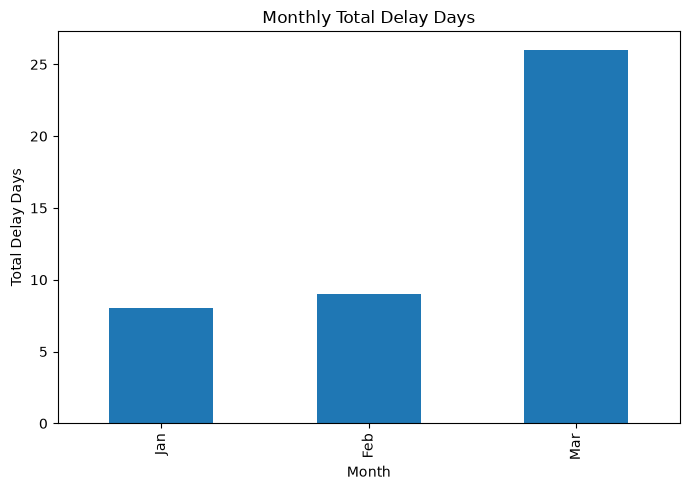

All P3 files saved successfully!


In [36]:
plt.figure(figsize=(7, 5))

monthly.plot(kind="bar")

plt.title("Monthly Total Delay Days")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")

plt.tight_layout()

# 3. Save chart
plt.savefig("outputs/python_chart.png")

# 4. Show chart
plt.show()


# 5. Export clean data
df.to_csv("outputs/clean_data.csv", index=False)

# 6. Export service-type summary
summary.to_csv("outputs/python_summary.csv", index=False)

print("All P3 files saved successfully!")

<Figure size 640x480 with 0 Axes>